In [1]:
import os
import time
import psutil
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize, RobustScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE



In [2]:
# ----------------- Reproducibility -----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"



Using: cuda


In [3]:
# ----------------- Data Cleaning -----------------
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))
print("Shape:", df.shape)


Shape: (427625, 25)


In [4]:
# ----------------- Custom Dataset -----------------
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [5]:
# ----------------- Model -----------------
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN branch
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.cnn_fc = nn.Linear(64, hidden_dim)

        # LSTM branch
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # Softmax fusion weights
        self.fusion_weights = nn.Parameter(torch.ones(2))

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN branch
        cnn_in = x.unsqueeze(1)  # (batch, 1, features)
        cnn_out = self.conv(cnn_in).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM branch
        lstm_in = x.unsqueeze(-1)  # (batch, features, 1)
        lstm_out, _ = self.lstm(lstm_in)
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # Fusion
        weights = torch.softmax(self.fusion_weights, dim=0)
        fused = weights[0] * cnn_feat + weights[1] * lstm_feat

        logits = self.classifier(fused)
        return logits  # No softmax



In [6]:
# ----------------- Training & Evaluation -----------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)

        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total


In [7]:

def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            prob = torch.softmax(logits, dim=1)

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs


# Borderline SMOTE

In [21]:


# ----------------- Pipeline -----------------
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # BEFORE SMOTE
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} BEFORE")
    plt.show()
    print("Train Data Class Distribution (BEFORE):")
    print(pd.Series(y_train).value_counts().sort_index())

    # BORDERLINE SMOTE
    try:
        smote = BorderlineSMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ BorderlineSMOTE failed:", e)

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} AFTER SMOTE")
    plt.show()
    print("Train Data Class Distribution (AFTER):")
    print(pd.Series(y_train).value_counts().sort_index())

    # SCALING
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # DATA LOADERS
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # MODEL
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)  # ✅ Fixed
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # TRAIN LOOP
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # PLOT LOSS & ACC
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # CONFUSION MATRIX
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()
    print(classification_report(true, preds))

    # ROC CURVE
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # PRECISION-RECALL CURVE
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    # RUNTIME + MEMORY
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")



========== 60:40 ==========


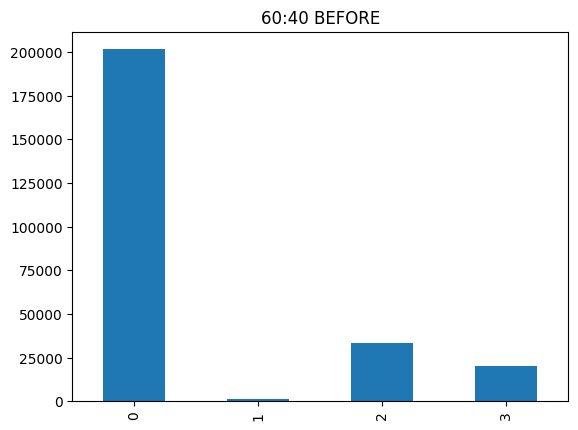

Train Data Class Distribution (BEFORE):
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


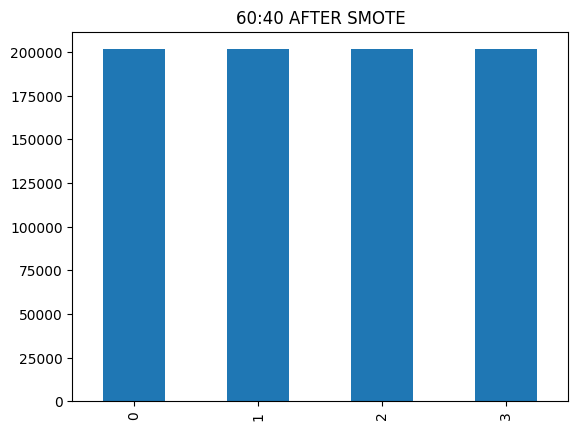

Train Data Class Distribution (AFTER):
0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1347, TrainAcc=0.9515, TestAcc=0.9655, ROC-AUC=0.9986
Epoch 2: Loss=0.0346, TrainAcc=0.9889, TestAcc=0.9794, ROC-AUC=0.9992
Epoch 3: Loss=0.0248, TrainAcc=0.9923, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 4: Loss=0.0224, TrainAcc=0.9935, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 5: Loss=0.0194, TrainAcc=0.9940, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 6: Loss=0.0182, TrainAcc=0.9943, TestAcc=0.9852, ROC-AUC=0.9994
Epoch 7: Loss=0.0179, TrainAcc=0.9945, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 8: Loss=0.0173, TrainAcc=0.9947, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 9: Loss=0.0169, TrainAcc=0.9947, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 10: Loss=0.0177, TrainAcc=0.9948, TestAcc=0.9865, ROC-AUC=0.9996
Epoch 11: Loss=0.0195, TrainAcc=0.9949, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 12: Loss=0.0170, TrainAcc=0.9950, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 13: Loss=0.0175, TrainAcc=0.9950, Test

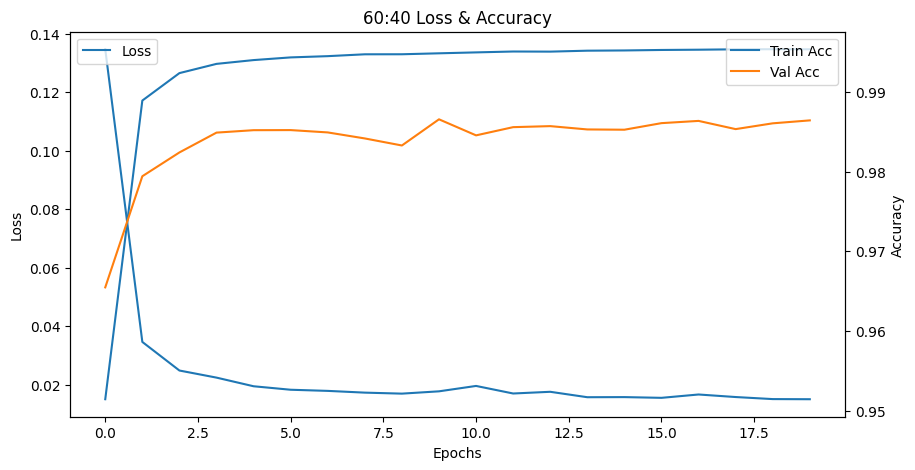

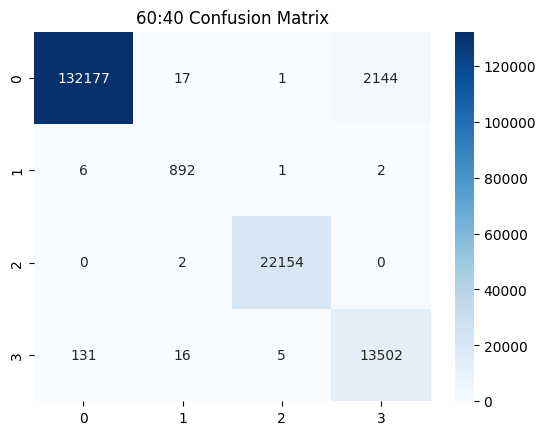

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.96      0.99      0.98       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.96      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



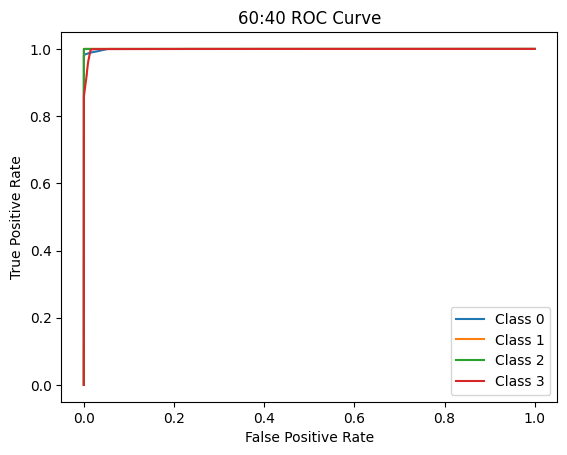

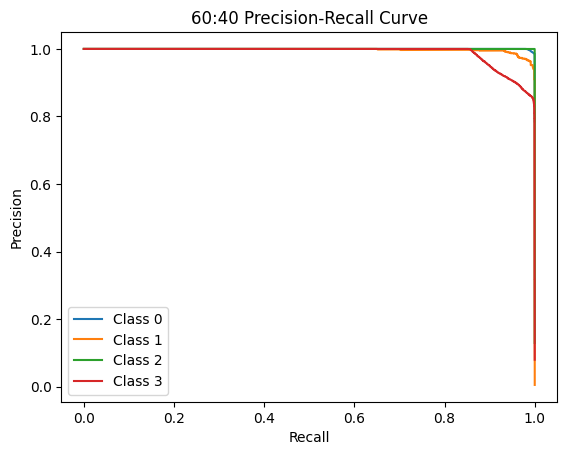

Runtime: 1260.91s
RAM Used: 471.13 MB

========== 70:30 ==========


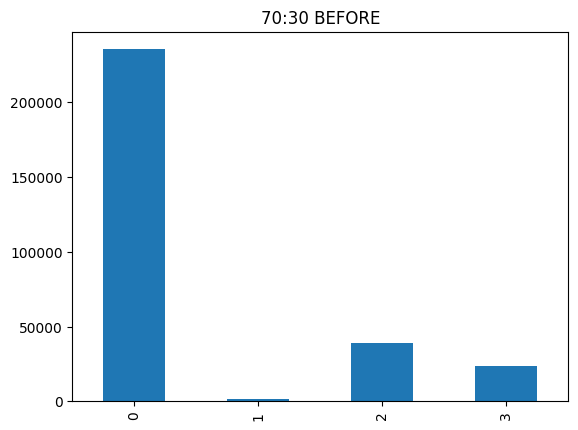

Train Data Class Distribution (BEFORE):
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


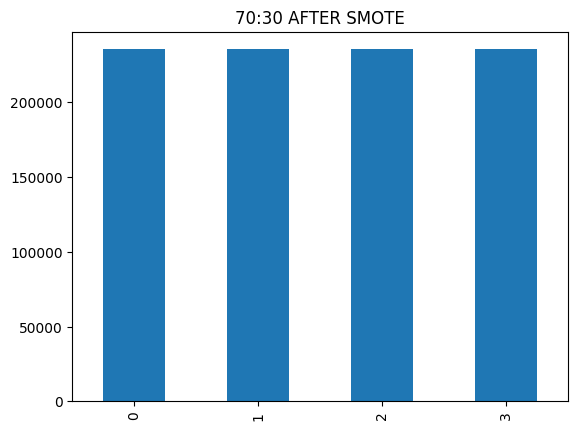

Train Data Class Distribution (AFTER):
0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.1196, TrainAcc=0.9578, TestAcc=0.9714, ROC-AUC=0.9987
Epoch 2: Loss=0.0325, TrainAcc=0.9897, TestAcc=0.9803, ROC-AUC=0.9992
Epoch 3: Loss=0.0279, TrainAcc=0.9922, TestAcc=0.9834, ROC-AUC=0.9992
Epoch 4: Loss=0.0233, TrainAcc=0.9931, TestAcc=0.9828, ROC-AUC=0.9995
Epoch 5: Loss=0.0211, TrainAcc=0.9937, TestAcc=0.9845, ROC-AUC=0.9994
Epoch 6: Loss=0.0212, TrainAcc=0.9941, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 7: Loss=0.0192, TrainAcc=0.9943, TestAcc=0.9822, ROC-AUC=0.9994
Epoch 8: Loss=0.0191, TrainAcc=0.9944, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 9: Loss=0.0197, TrainAcc=0.9946, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 10: Loss=0.0187, TrainAcc=0.9947, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 11: Loss=0.0177, TrainAcc=0.9948, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 12: Loss=0.0174, TrainAcc=0.9948, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 13: Loss=0.0173, TrainAcc=0.9949, Test

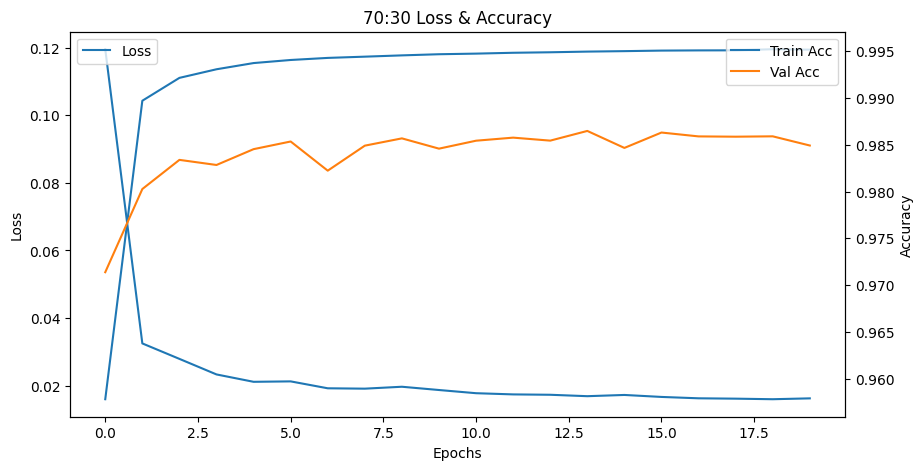

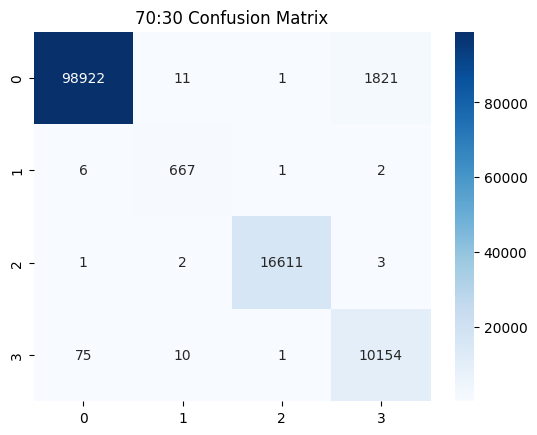

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.97      0.99      0.98       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.99      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.98      0.99    128288



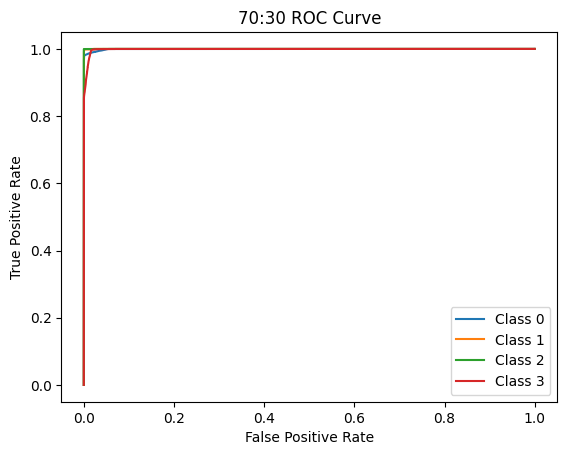

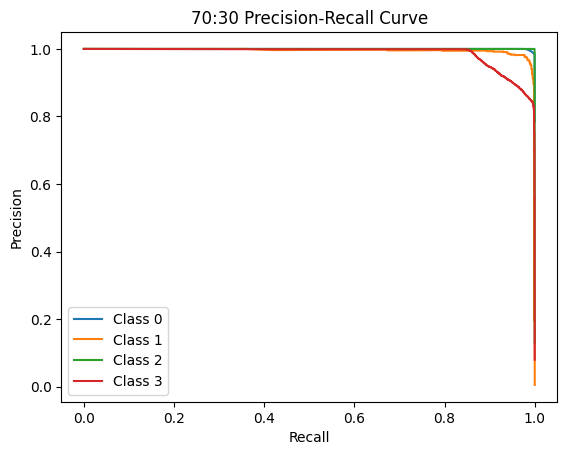

Runtime: 1444.93s
RAM Used: 425.83 MB

========== 80:20 ==========


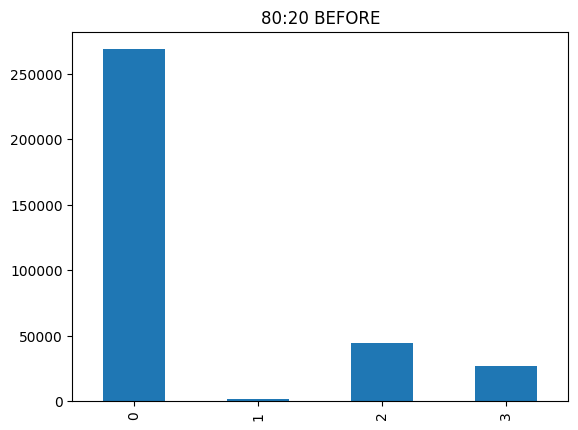

Train Data Class Distribution (BEFORE):
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


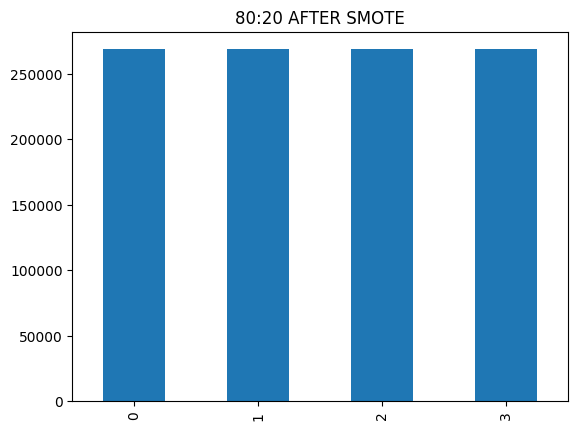

Train Data Class Distribution (AFTER):
0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.1140, TrainAcc=0.9602, TestAcc=0.9694, ROC-AUC=0.9989
Epoch 2: Loss=0.0296, TrainAcc=0.9906, TestAcc=0.9843, ROC-AUC=0.9993
Epoch 3: Loss=0.0231, TrainAcc=0.9931, TestAcc=0.9843, ROC-AUC=0.9994
Epoch 4: Loss=0.0206, TrainAcc=0.9939, TestAcc=0.9834, ROC-AUC=0.9995
Epoch 5: Loss=0.0199, TrainAcc=0.9943, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 6: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 7: Loss=0.0182, TrainAcc=0.9947, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 8: Loss=0.0174, TrainAcc=0.9948, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 9: Loss=0.0169, TrainAcc=0.9949, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 10: Loss=0.0176, TrainAcc=0.9950, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 11: Loss=0.0164, TrainAcc=0.9950, TestAcc=0.9864, ROC-AUC=0.9996
Epoch 12: Loss=0.0164, TrainAcc=0.9951, TestAcc=0.9864, ROC-AUC=0.9995
Epoch 13: Loss=0.0168, TrainAcc=0.9951, Test

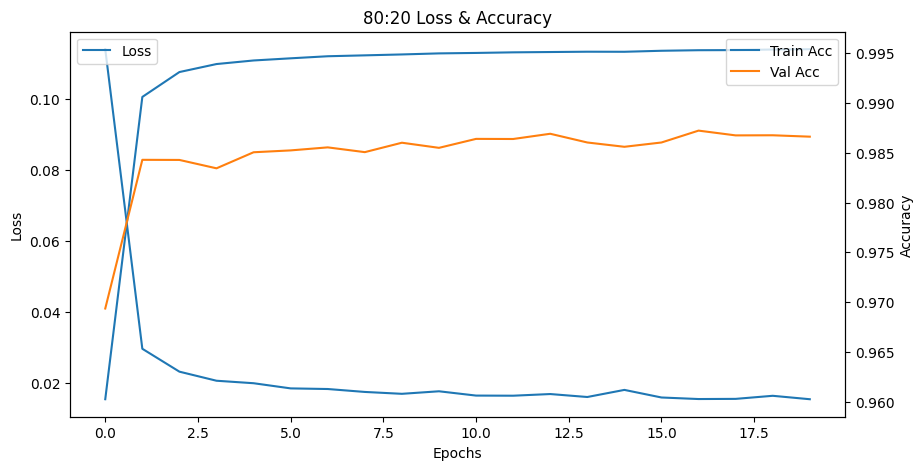

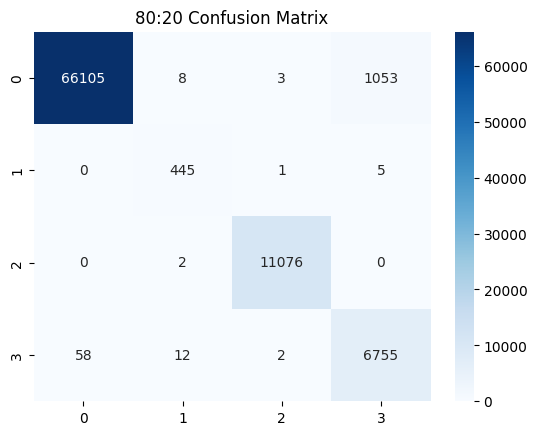

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.95      0.99      0.97       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.95      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



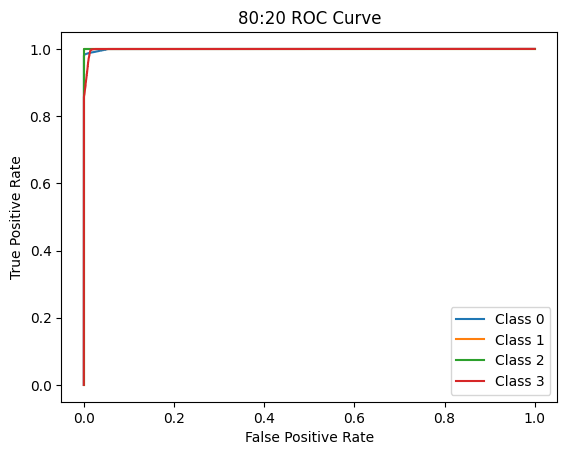

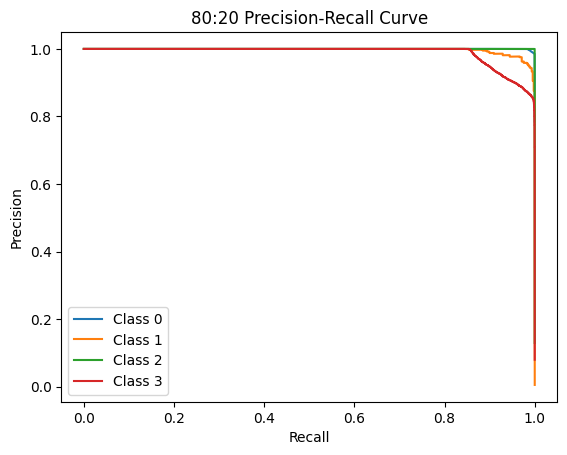

Runtime: 1609.49s
RAM Used: 487.59 MB


In [22]:

# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", 0.4)
run_split(df, "70:30", 0.3)
run_split(df, "80:20", 0.2)

# SMOTE

In [23]:
# ----------------- Pipeline with Regular SMOTE -----------------
from imblearn.over_sampling import SMOTE

def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (Regular SMOTE) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # BEFORE SMOTE
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} BEFORE")
    plt.show()
    print("Train Data Class Distribution (BEFORE):")
    print(pd.Series(y_train).value_counts().sort_index())

    # REGULAR SMOTE
    try:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ SMOTE failed:", e)

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} AFTER SMOTE")
    plt.show()
    print("Train Data Class Distribution (AFTER):")
    print(pd.Series(y_train).value_counts().sort_index())

    # SCALING
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # DATA LOADERS
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # MODEL
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # TRAIN LOOP
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # PLOT LOSS & ACC
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # CONFUSION MATRIX
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()
    print(classification_report(true, preds))

    # ROC CURVE
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # PRECISION-RECALL CURVE
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    # RUNTIME + MEMORY
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 (Regular SMOTE) ==========


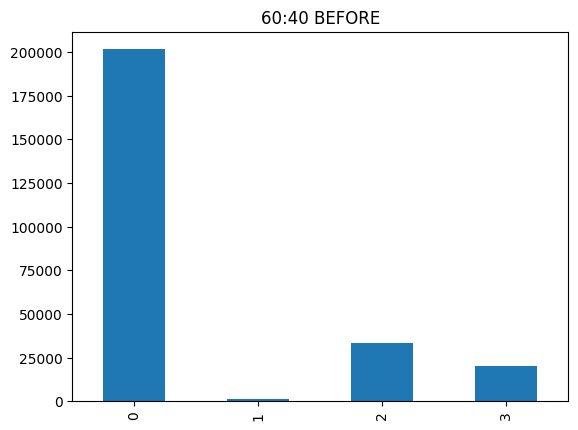

Train Data Class Distribution (BEFORE):
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


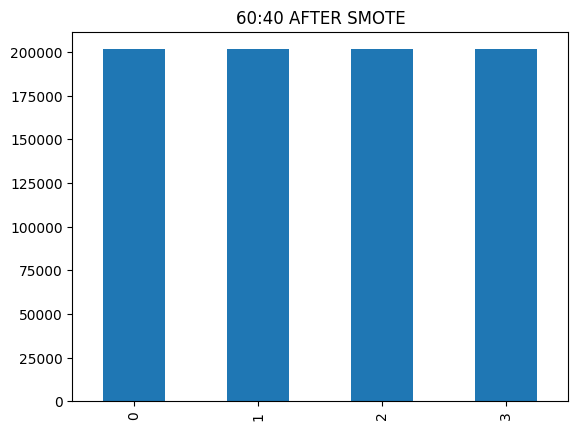

Train Data Class Distribution (AFTER):
0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1189, TrainAcc=0.9571, TestAcc=0.9708, ROC-AUC=0.9991
Epoch 2: Loss=0.0291, TrainAcc=0.9900, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 3: Loss=0.0229, TrainAcc=0.9920, TestAcc=0.9805, ROC-AUC=0.9994
Epoch 4: Loss=0.0197, TrainAcc=0.9932, TestAcc=0.9819, ROC-AUC=0.9995
Epoch 5: Loss=0.0181, TrainAcc=0.9938, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 6: Loss=0.0168, TrainAcc=0.9941, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 7: Loss=0.0160, TrainAcc=0.9945, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 8: Loss=0.0153, TrainAcc=0.9947, TestAcc=0.9865, ROC-AUC=0.9995
Epoch 9: Loss=0.0152, TrainAcc=0.9948, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 10: Loss=0.0163, TrainAcc=0.9949, TestAcc=0.9863, ROC-AUC=0.9996
Epoch 11: Loss=0.0146, TrainAcc=0.9951, TestAcc=0.9861, ROC-AUC=0.9995
Epoch 12: Loss=0.0141, TrainAcc=0.9952, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 13: Loss=0.0139, TrainAcc=0.9952, Test

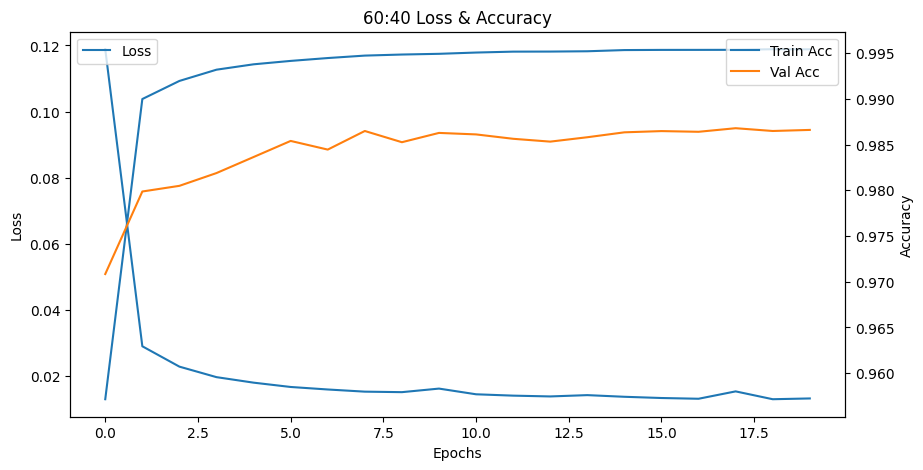

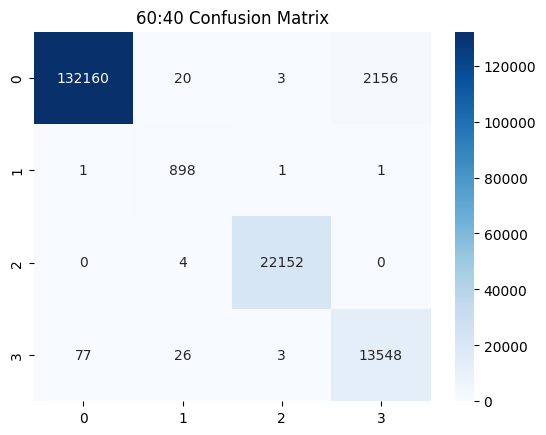

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.95      1.00      0.97       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.95      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



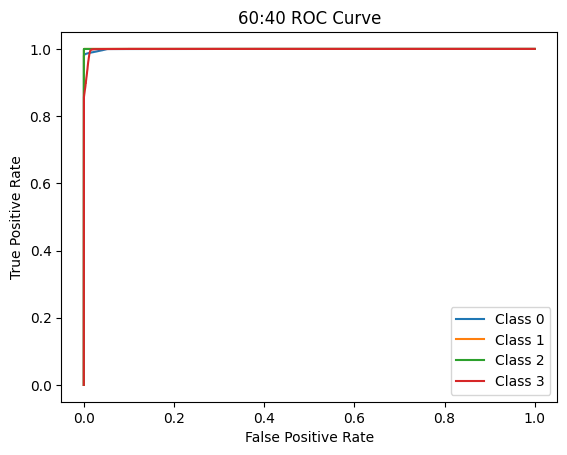

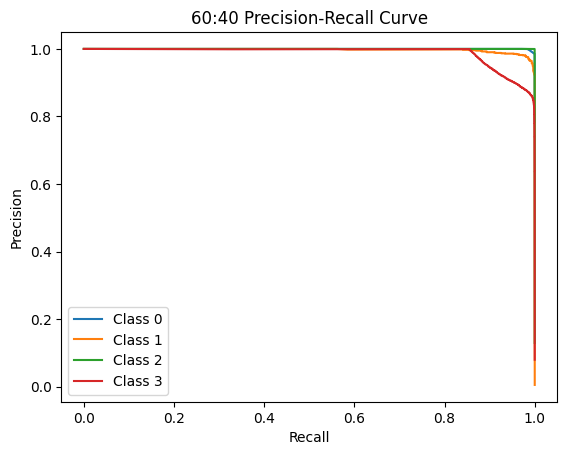

Runtime: 1251.56s
RAM Used: -4.43 MB

========== 70:30 (Regular SMOTE) ==========


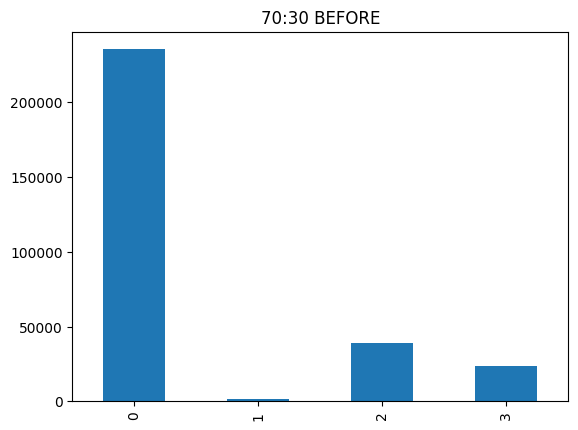

Train Data Class Distribution (BEFORE):
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


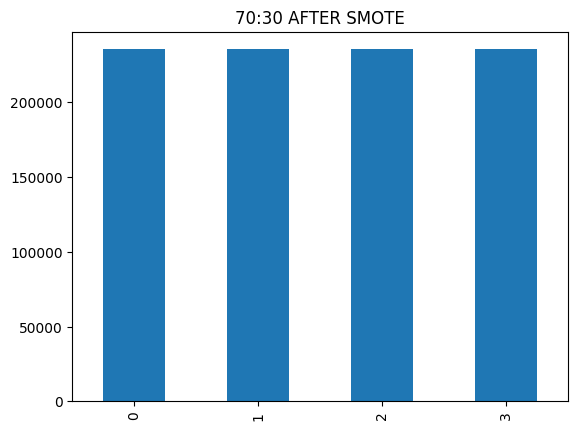

Train Data Class Distribution (AFTER):
0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.1218, TrainAcc=0.9563, TestAcc=0.9696, ROC-AUC=0.9988
Epoch 2: Loss=0.0320, TrainAcc=0.9892, TestAcc=0.9790, ROC-AUC=0.9993
Epoch 3: Loss=0.0251, TrainAcc=0.9919, TestAcc=0.9834, ROC-AUC=0.9995
Epoch 4: Loss=0.0207, TrainAcc=0.9931, TestAcc=0.9814, ROC-AUC=0.9995
Epoch 5: Loss=0.0196, TrainAcc=0.9937, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 6: Loss=0.0255, TrainAcc=0.9940, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 7: Loss=0.0178, TrainAcc=0.9943, TestAcc=0.9859, ROC-AUC=0.9996
Epoch 8: Loss=0.0159, TrainAcc=0.9945, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 9: Loss=0.0160, TrainAcc=0.9946, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 10: Loss=0.0168, TrainAcc=0.9948, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 11: Loss=0.0153, TrainAcc=0.9948, TestAcc=0.9856, ROC-AUC=0.9996
Epoch 12: Loss=0.0147, TrainAcc=0.9950, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 13: Loss=0.0146, TrainAcc=0.9950, Test

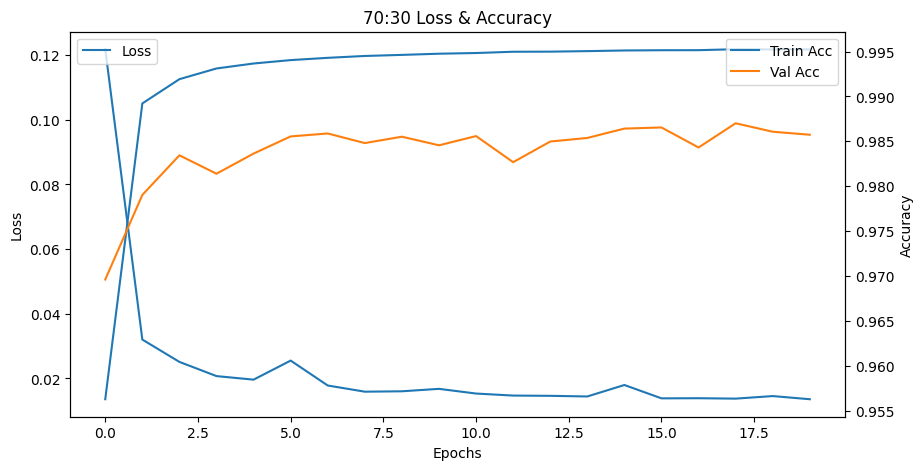

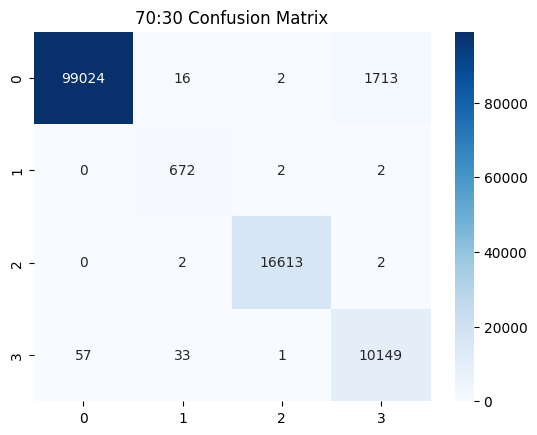

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.93      0.99      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



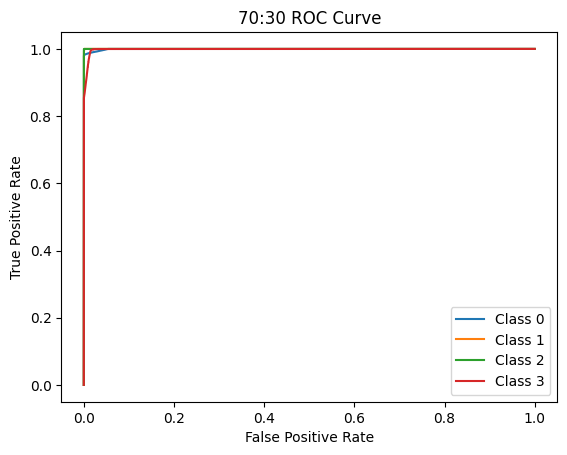

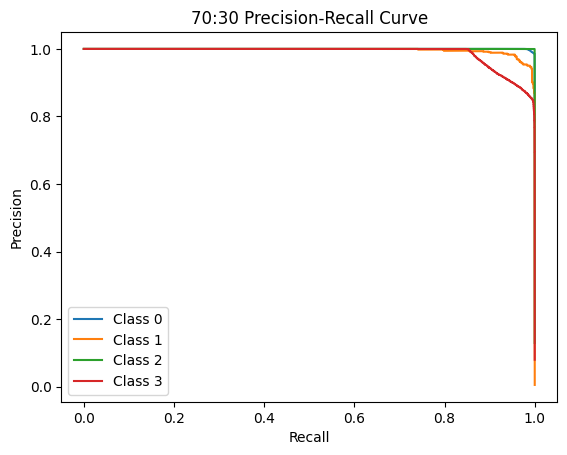

Runtime: 1394.12s
RAM Used: 389.75 MB

========== 80:20 (Regular SMOTE) ==========


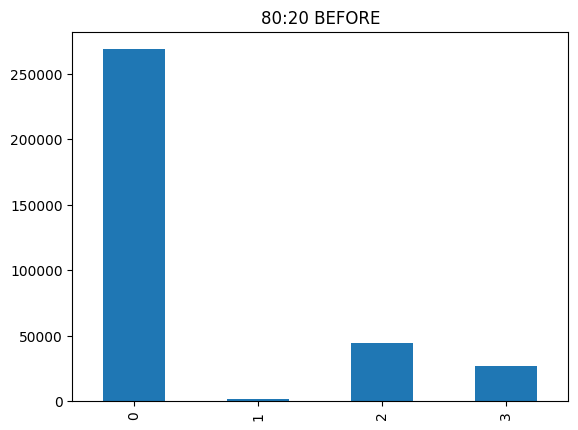

Train Data Class Distribution (BEFORE):
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


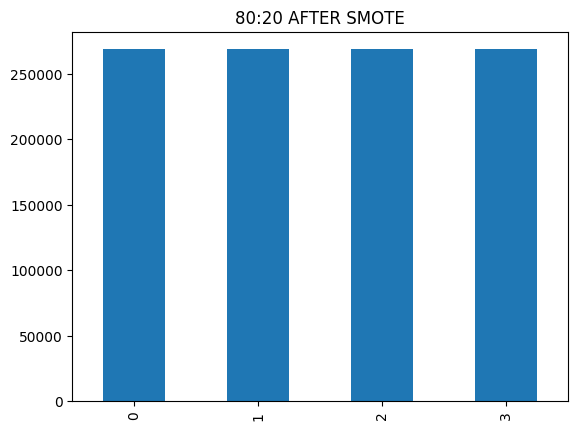

Train Data Class Distribution (AFTER):
0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.1033, TrainAcc=0.9631, TestAcc=0.9732, ROC-AUC=0.9990
Epoch 2: Loss=0.0258, TrainAcc=0.9912, TestAcc=0.9834, ROC-AUC=0.9994
Epoch 3: Loss=0.0206, TrainAcc=0.9931, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 4: Loss=0.0182, TrainAcc=0.9938, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 5: Loss=0.0173, TrainAcc=0.9942, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 6: Loss=0.0168, TrainAcc=0.9944, TestAcc=0.9851, ROC-AUC=0.9996
Epoch 7: Loss=0.0161, TrainAcc=0.9945, TestAcc=0.9858, ROC-AUC=0.9996
Epoch 8: Loss=0.0154, TrainAcc=0.9948, TestAcc=0.9846, ROC-AUC=0.9986
Epoch 9: Loss=0.0164, TrainAcc=0.9948, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 10: Loss=0.0153, TrainAcc=0.9949, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 11: Loss=0.0147, TrainAcc=0.9950, TestAcc=0.9863, ROC-AUC=0.9995
Epoch 12: Loss=0.0154, TrainAcc=0.9950, TestAcc=0.9867, ROC-AUC=0.9996
Epoch 13: Loss=0.0149, TrainAcc=0.9951, Test

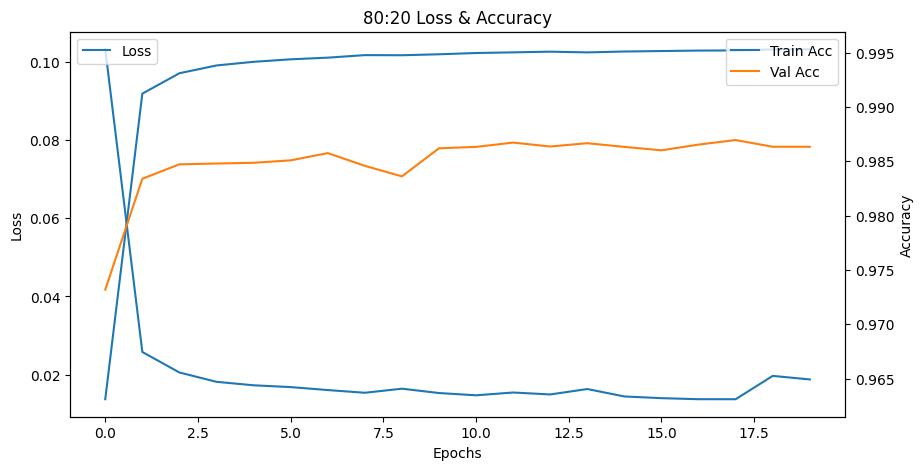

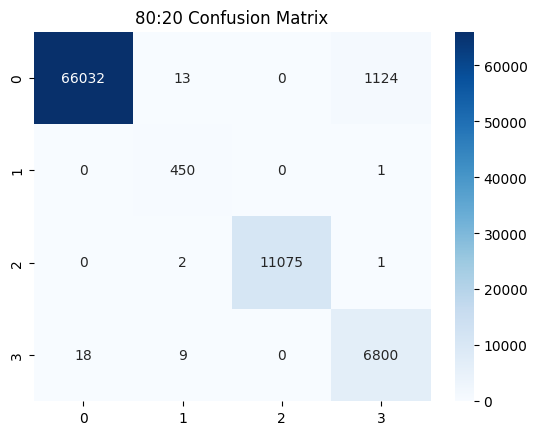

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.95      1.00      0.97       451
           2       1.00      1.00      1.00     11078
           3       0.86      1.00      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.95      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



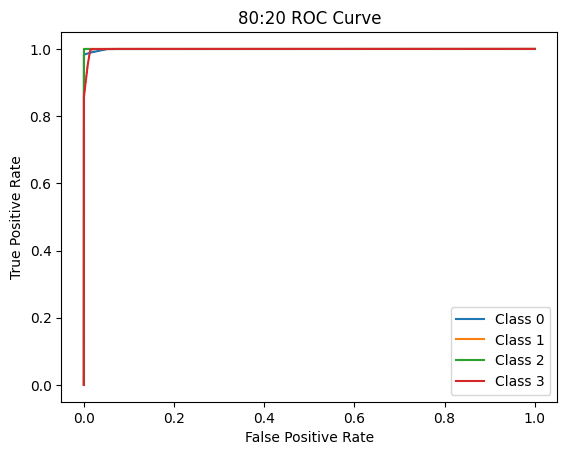

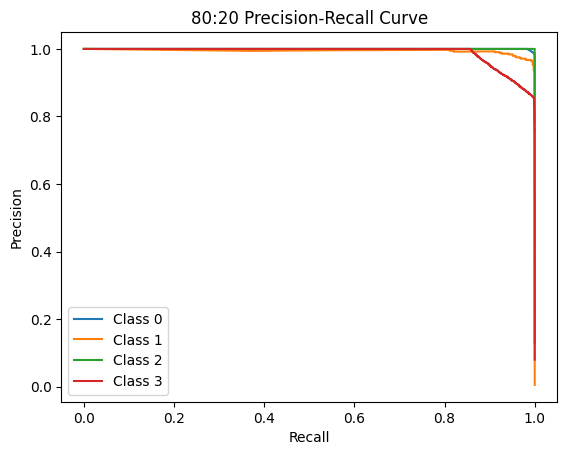

Runtime: 1490.99s
RAM Used: 377.43 MB


In [24]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", 0.4)
run_split_smote(df, "70:30", 0.3)
run_split_smote(df, "80:20", 0.2)

# ADASYN

In [25]:
# ----------------- Pipeline with ADASYN -----------------
from imblearn.over_sampling import ADASYN

def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (ADASYN) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # BEFORE ADASYN
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} BEFORE")
    plt.show()
    print("Train Data Class Distribution (BEFORE):")
    print(pd.Series(y_train).value_counts().sort_index())

    # ADASYN
    try:
        adasyn = ADASYN(random_state=42)
        X_train, y_train = adasyn.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ ADASYN failed:", e)

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} AFTER ADASYN")
    plt.show()
    print("Train Data Class Distribution (AFTER):")
    print(pd.Series(y_train).value_counts().sort_index())

    # SCALING
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # DATA LOADERS
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # MODEL
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # TRAIN LOOP
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # PLOT LOSS & ACC
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # CONFUSION MATRIX
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()
    print(classification_report(true, preds))

    # ROC CURVE
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # PRECISION-RECALL CURVE
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    # RUNTIME + MEMORY
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 (ADASYN) ==========


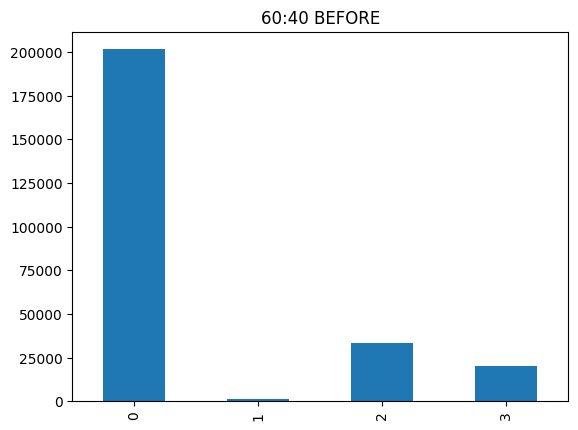

Train Data Class Distribution (BEFORE):
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


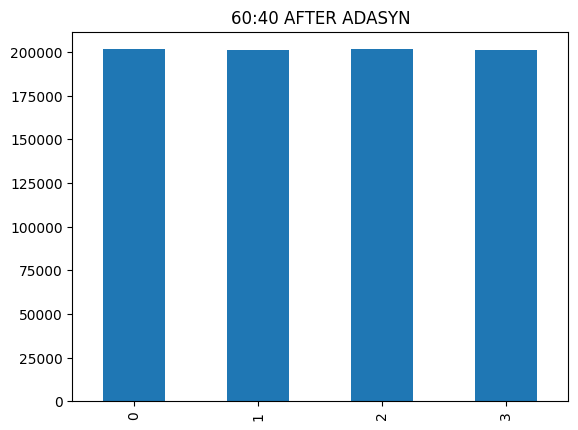

Train Data Class Distribution (AFTER):
0    201508
1    201439
2    201546
3    200949
Name: count, dtype: int64
Epoch 1: Loss=0.1325, TrainAcc=0.9519, TestAcc=0.9657, ROC-AUC=0.9987
Epoch 2: Loss=0.0356, TrainAcc=0.9882, TestAcc=0.9785, ROC-AUC=0.9992
Epoch 3: Loss=0.0277, TrainAcc=0.9918, TestAcc=0.9792, ROC-AUC=0.9993
Epoch 4: Loss=0.0234, TrainAcc=0.9929, TestAcc=0.9801, ROC-AUC=0.9994
Epoch 5: Loss=0.0216, TrainAcc=0.9933, TestAcc=0.9840, ROC-AUC=0.9994
Epoch 6: Loss=0.0197, TrainAcc=0.9939, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 7: Loss=0.0183, TrainAcc=0.9942, TestAcc=0.9859, ROC-AUC=0.9996
Epoch 8: Loss=0.0182, TrainAcc=0.9944, TestAcc=0.9824, ROC-AUC=0.9995
Epoch 9: Loss=0.0175, TrainAcc=0.9946, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 10: Loss=0.0169, TrainAcc=0.9947, TestAcc=0.9848, ROC-AUC=0.9994
Epoch 11: Loss=0.0167, TrainAcc=0.9948, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 12: Loss=0.0162, TrainAcc=0.9949, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 13: Loss=0.0237, TrainAcc=0.9950, Test

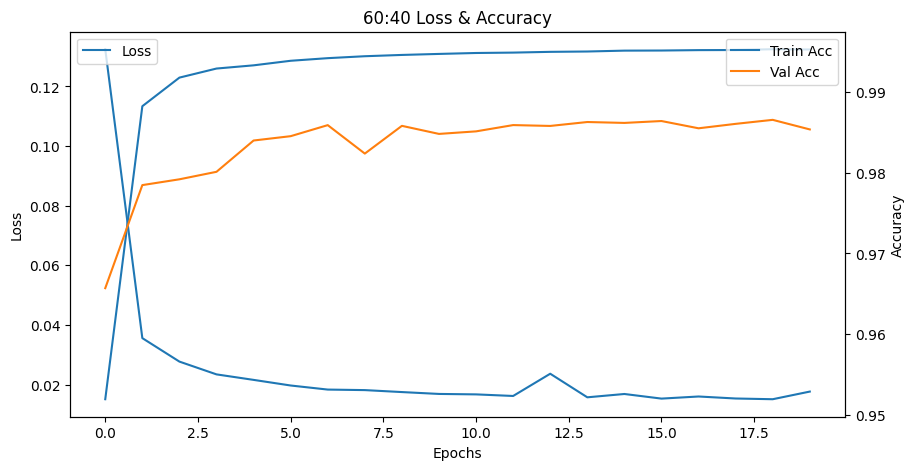

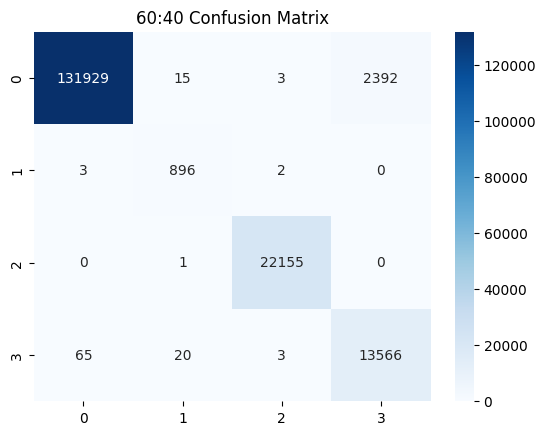

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.96      0.99      0.98       901
           2       1.00      1.00      1.00     22156
           3       0.85      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.95      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



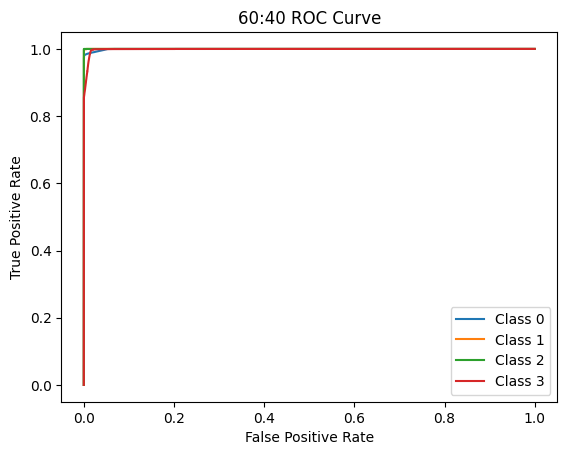

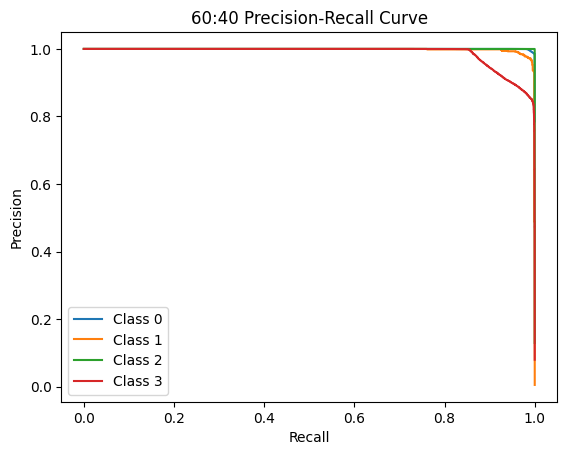

Runtime: 1215.50s
RAM Used: 358.67 MB

========== 70:30 (ADASYN) ==========


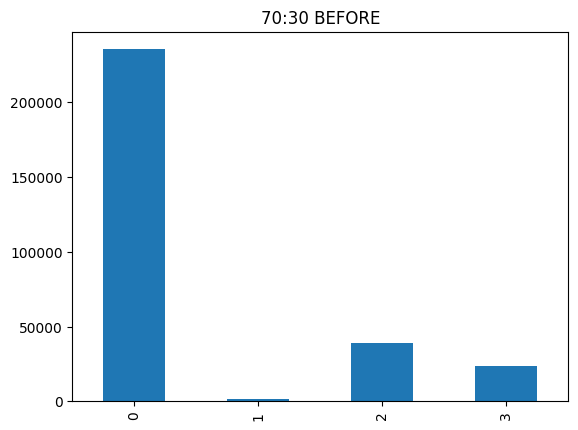

Train Data Class Distribution (BEFORE):
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


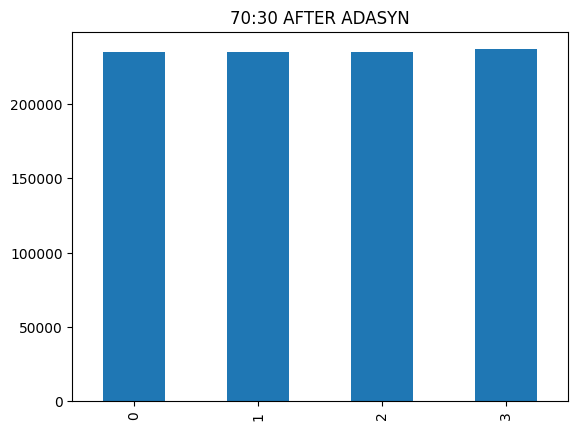

Train Data Class Distribution (AFTER):
0    235092
1    235149
2    235089
3    236755
Name: count, dtype: int64
Epoch 1: Loss=0.1492, TrainAcc=0.9457, TestAcc=0.9770, ROC-AUC=0.9984
Epoch 2: Loss=0.0352, TrainAcc=0.9890, TestAcc=0.9773, ROC-AUC=0.9992
Epoch 3: Loss=0.0258, TrainAcc=0.9919, TestAcc=0.9820, ROC-AUC=0.9994
Epoch 4: Loss=0.0222, TrainAcc=0.9932, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 5: Loss=0.0228, TrainAcc=0.9938, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 6: Loss=0.0188, TrainAcc=0.9941, TestAcc=0.9849, ROC-AUC=0.9996
Epoch 7: Loss=0.0186, TrainAcc=0.9943, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 8: Loss=0.0176, TrainAcc=0.9945, TestAcc=0.9851, ROC-AUC=0.9996
Epoch 9: Loss=0.0172, TrainAcc=0.9946, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 10: Loss=0.0168, TrainAcc=0.9947, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 11: Loss=0.0167, TrainAcc=0.9949, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 12: Loss=0.0171, TrainAcc=0.9949, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 13: Loss=0.0161, TrainAcc=0.9950, Test

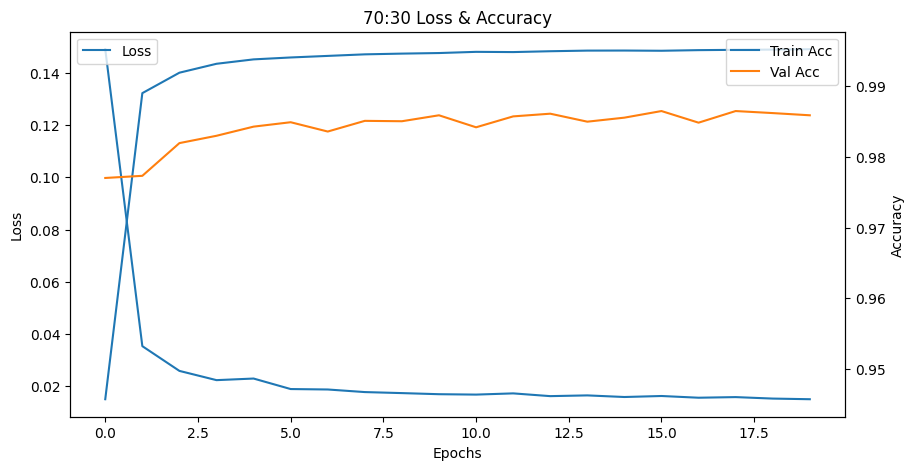

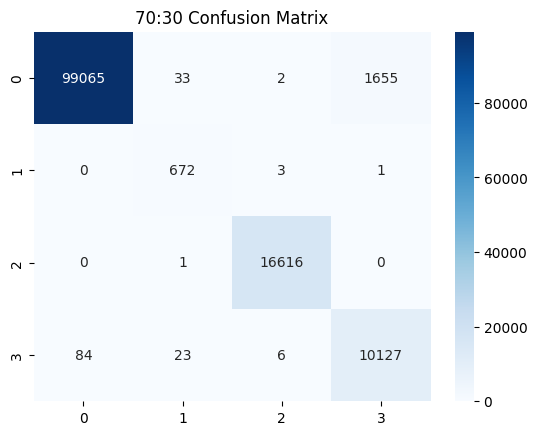

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.92      0.99      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



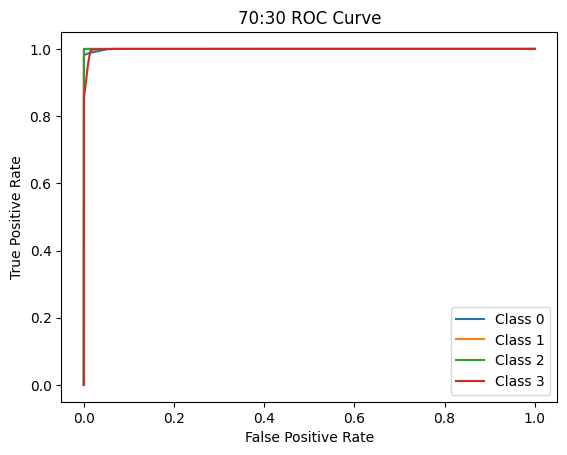

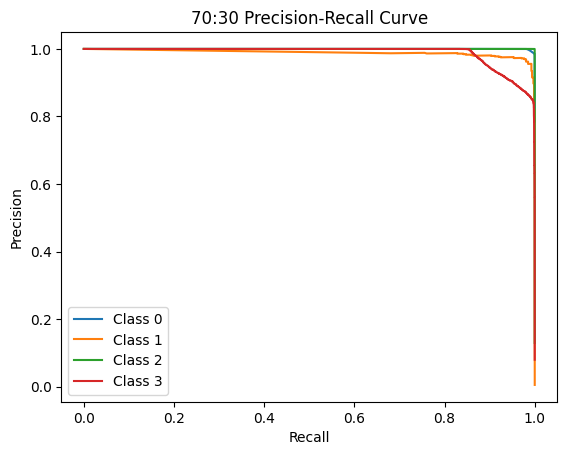

Runtime: 1439.85s
RAM Used: 384.00 MB

========== 80:20 (ADASYN) ==========


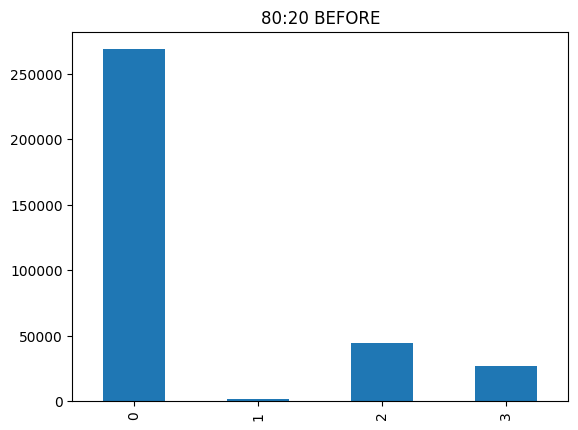

Train Data Class Distribution (BEFORE):
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


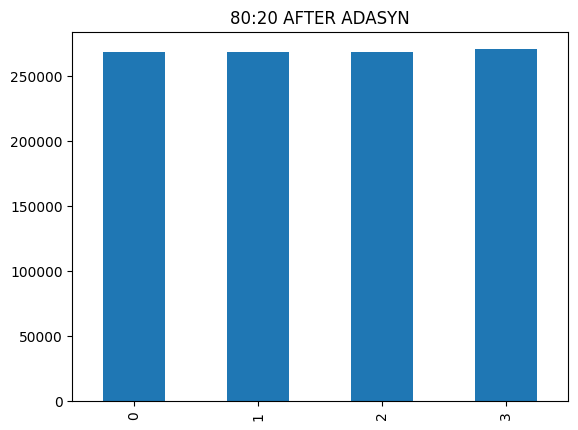

Train Data Class Distribution (AFTER):
0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64
Epoch 1: Loss=0.1441, TrainAcc=0.9477, TestAcc=0.9680, ROC-AUC=0.9986
Epoch 2: Loss=0.0357, TrainAcc=0.9887, TestAcc=0.9780, ROC-AUC=0.9993
Epoch 3: Loss=0.0261, TrainAcc=0.9920, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 4: Loss=0.0228, TrainAcc=0.9931, TestAcc=0.9781, ROC-AUC=0.9990
Epoch 5: Loss=0.0208, TrainAcc=0.9937, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 6: Loss=0.0199, TrainAcc=0.9940, TestAcc=0.9851, ROC-AUC=0.9994
Epoch 7: Loss=0.0192, TrainAcc=0.9943, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 8: Loss=0.0187, TrainAcc=0.9945, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 9: Loss=0.0177, TrainAcc=0.9945, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 10: Loss=0.0174, TrainAcc=0.9947, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 11: Loss=0.0229, TrainAcc=0.9948, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9949, TestAcc=0.9857, ROC-AUC=0.9994
Epoch 13: Loss=0.0166, TrainAcc=0.9949, Test

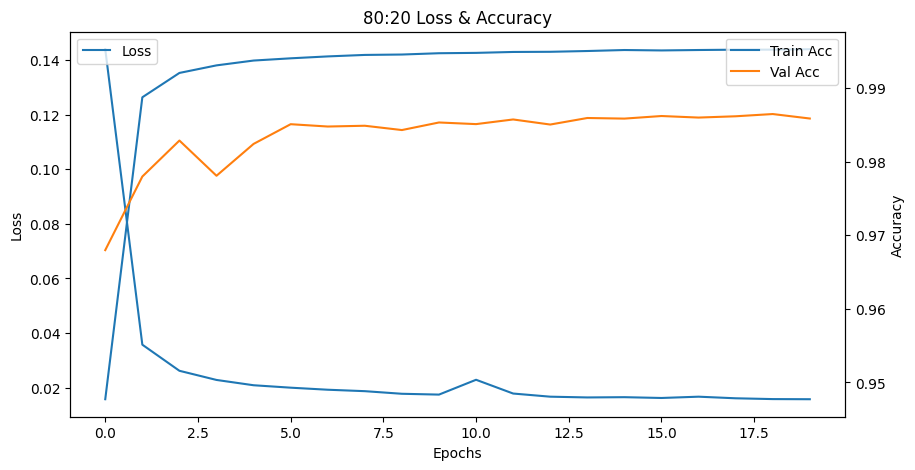

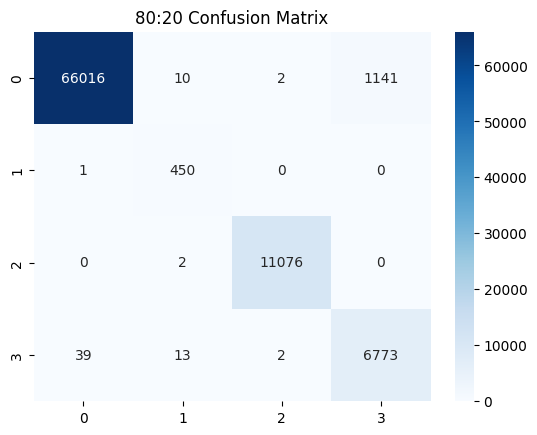

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.95      1.00      0.97       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.95      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



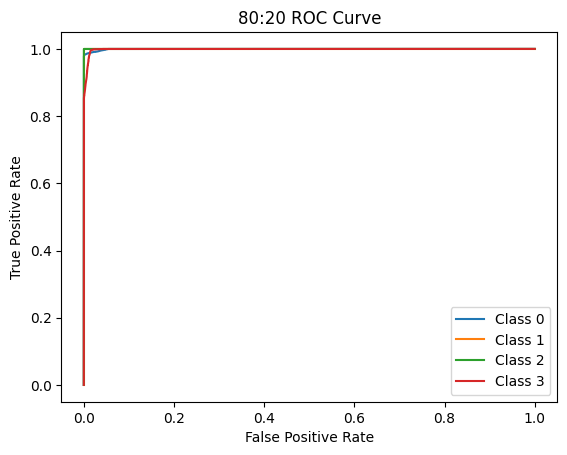

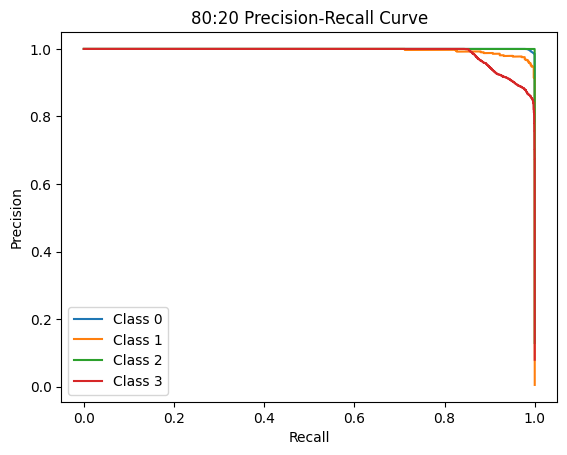

Runtime: 1623.78s
RAM Used: 377.90 MB


In [26]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", 0.4)
run_split_adasyn(df, "70:30", 0.3)
run_split_adasyn(df, "80:20", 0.2)

# ADASYN + TomekLinks


In [8]:
# ----------------- Pipeline with ADASYN + Tomek Links -----------------
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (ADASYN + Tomek Links) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # BEFORE ADASYN + Tomek
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} BEFORE")
    plt.show()
    print("Train Data Class Distribution (BEFORE):")
    print(pd.Series(y_train).value_counts().sort_index())

    # ADASYN + Tomek Links
    try:
        from imblearn.combine import SMOTETomek
        # SMOTETomek allows specifying ADASYN instead of SMOTE
        from imblearn.over_sampling import ADASYN
        adasyn = ADASYN(random_state=42)
        tomek = TomekLinks()
        X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
        X_train, y_train = tomek.fit_resample(X_train_res, y_train_res)
    except Exception as e:
        print("⚠️ ADASYN + Tomek Links failed:", e)

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} AFTER ADASYN + Tomek")
    plt.show()
    print("Train Data Class Distribution (AFTER):")
    print(pd.Series(y_train).value_counts().sort_index())

    # SCALING
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # DATA LOADERS
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # MODEL
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # TRAIN LOOP
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # PLOT LOSS & ACC
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # CONFUSION MATRIX
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()
    print(classification_report(true, preds))

    # ROC CURVE
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # PRECISION-RECALL CURVE
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    # RUNTIME + MEMORY
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 (ADASYN + Tomek Links) ==========


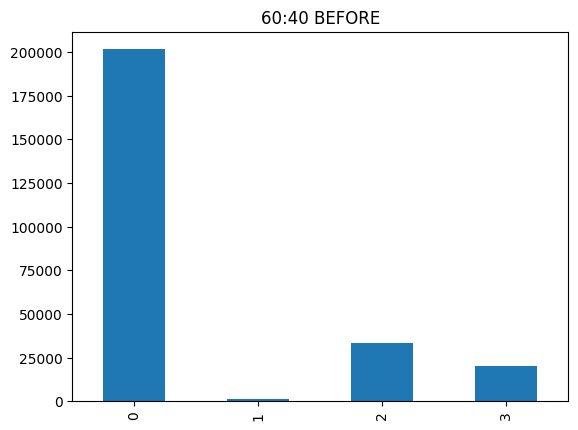

Train Data Class Distribution (BEFORE):
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


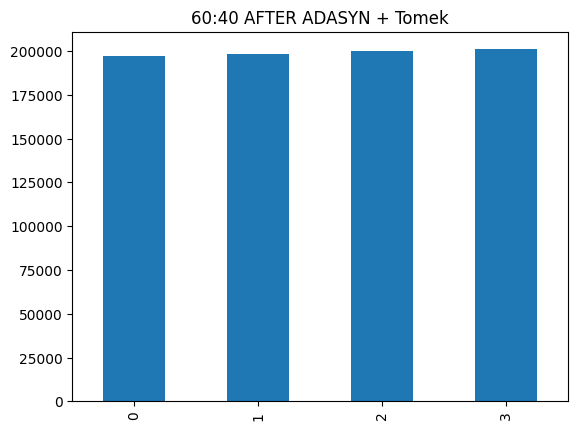

Train Data Class Distribution (AFTER):
0    197264
1    198377
2    199951
3    200949
Name: count, dtype: int64
Epoch 1: Loss=0.1645, TrainAcc=0.9403, TestAcc=0.9632, ROC-AUC=0.9981
Epoch 2: Loss=0.0420, TrainAcc=0.9866, TestAcc=0.9759, ROC-AUC=0.9989
Epoch 3: Loss=0.0269, TrainAcc=0.9916, TestAcc=0.9812, ROC-AUC=0.9994
Epoch 4: Loss=0.0228, TrainAcc=0.9930, TestAcc=0.9834, ROC-AUC=0.9994
Epoch 5: Loss=0.0202, TrainAcc=0.9937, TestAcc=0.9849, ROC-AUC=0.9994
Epoch 6: Loss=0.0192, TrainAcc=0.9943, TestAcc=0.9830, ROC-AUC=0.9995
Epoch 7: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 8: Loss=0.0170, TrainAcc=0.9948, TestAcc=0.9850, ROC-AUC=0.9994
Epoch 9: Loss=0.0164, TrainAcc=0.9949, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 10: Loss=0.0160, TrainAcc=0.9951, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 11: Loss=0.0159, TrainAcc=0.9952, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 12: Loss=0.0154, TrainAcc=0.9953, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 13: Loss=0.0155, TrainAcc=0.9953, Test

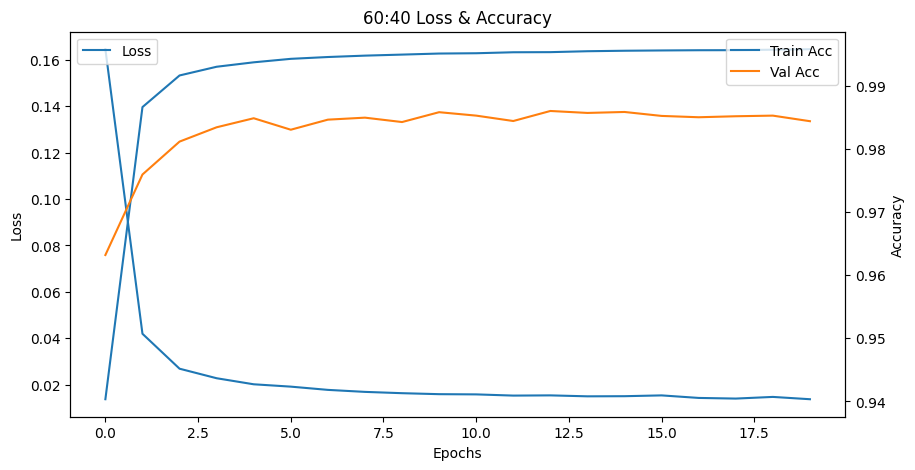

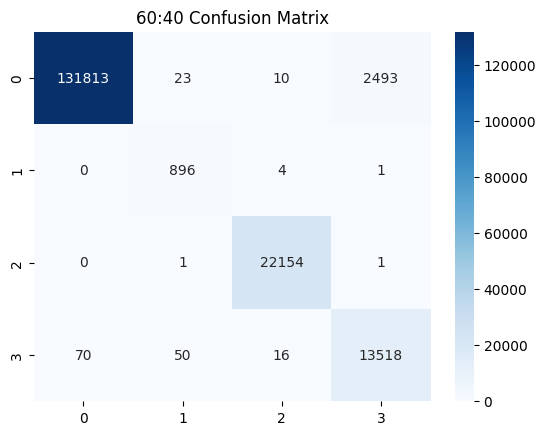

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.92      0.99      0.96       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.99      0.91     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.98      0.98    171050



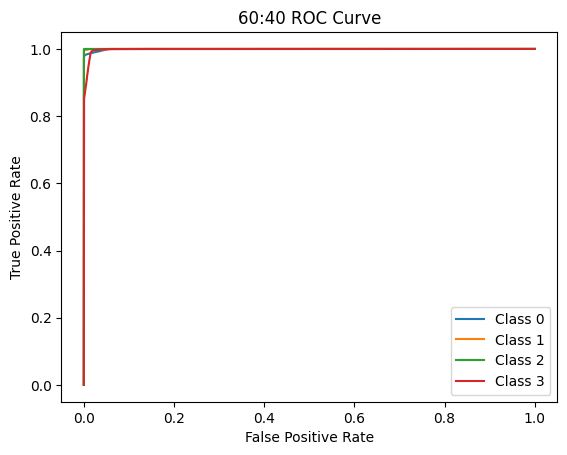

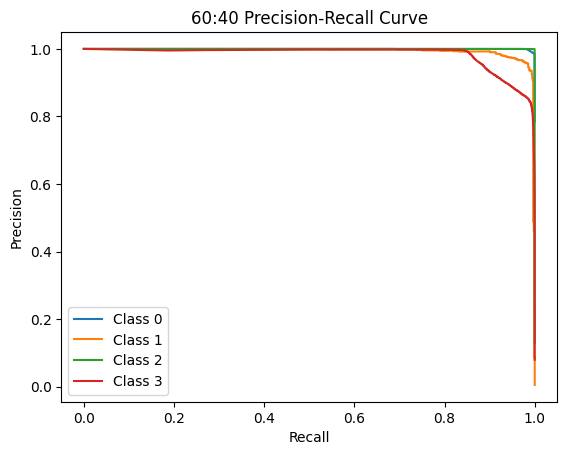

Runtime: 3050.69s
RAM Used: 477.95 MB

========== 70:30 (ADASYN + Tomek Links) ==========


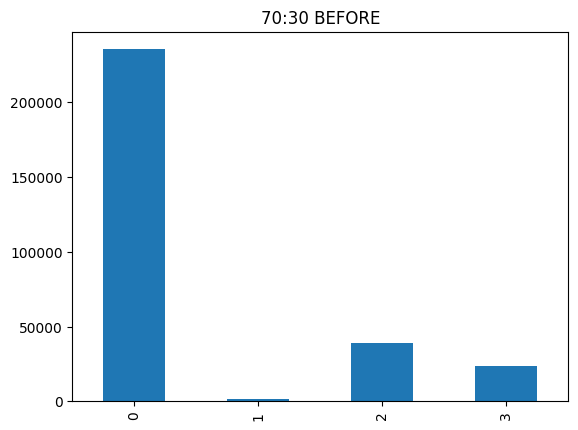

Train Data Class Distribution (BEFORE):
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


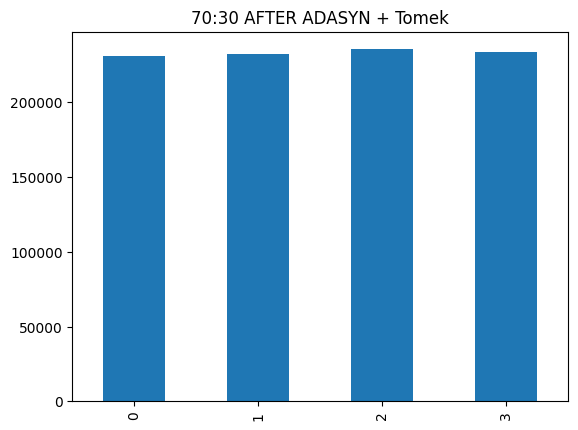

Train Data Class Distribution (AFTER):
0    230618
1    231924
2    235089
3    233504
Name: count, dtype: int64
Epoch 1: Loss=0.1722, TrainAcc=0.9379, TestAcc=0.9633, ROC-AUC=0.9984
Epoch 2: Loss=0.0431, TrainAcc=0.9863, TestAcc=0.9745, ROC-AUC=0.9991
Epoch 3: Loss=0.0291, TrainAcc=0.9908, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 4: Loss=0.0238, TrainAcc=0.9927, TestAcc=0.9815, ROC-AUC=0.9995
Epoch 5: Loss=0.0210, TrainAcc=0.9936, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 6: Loss=0.0197, TrainAcc=0.9942, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 7: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 8: Loss=0.0175, TrainAcc=0.9947, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 9: Loss=0.0169, TrainAcc=0.9949, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 10: Loss=0.0164, TrainAcc=0.9951, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 11: Loss=0.0163, TrainAcc=0.9952, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 12: Loss=0.0176, TrainAcc=0.9953, TestAcc=0.9864, ROC-AUC=0.9996
Epoch 13: Loss=0.0152, TrainAcc=0.9954, Test

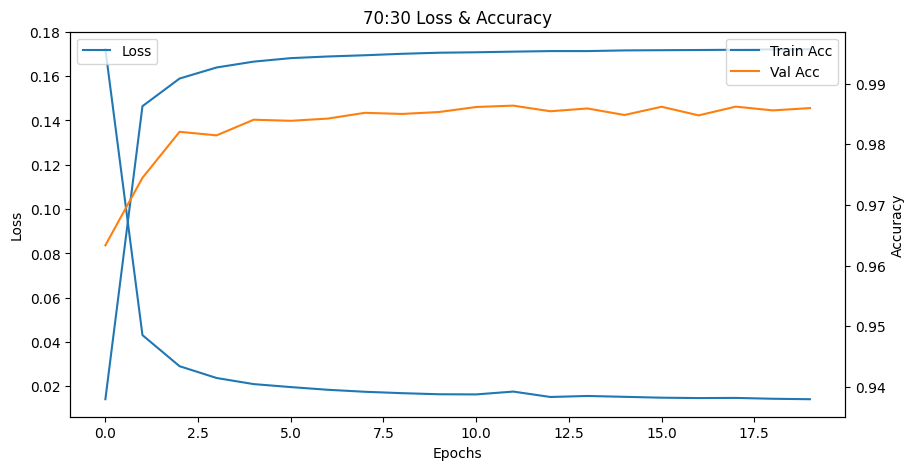

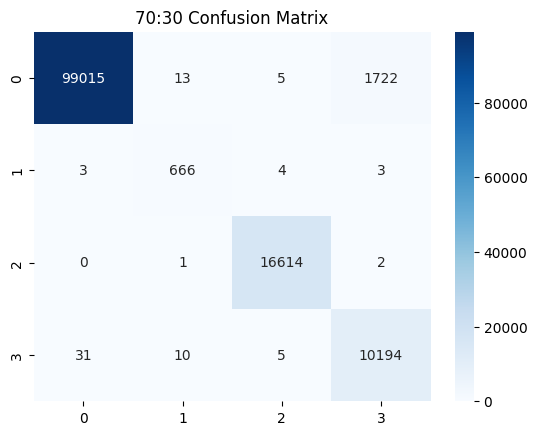

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.97      0.99      0.98       676
           2       1.00      1.00      1.00     16617
           3       0.86      1.00      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



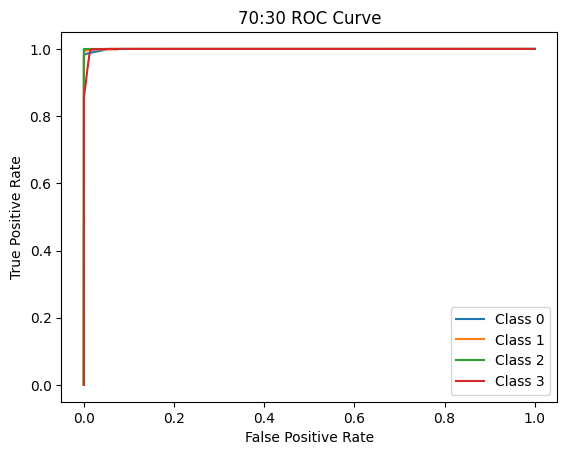

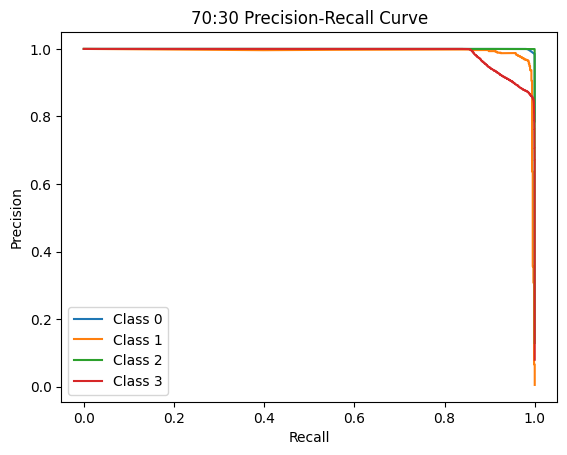

Runtime: 3876.44s
RAM Used: 553.47 MB

========== 80:20 (ADASYN + Tomek Links) ==========


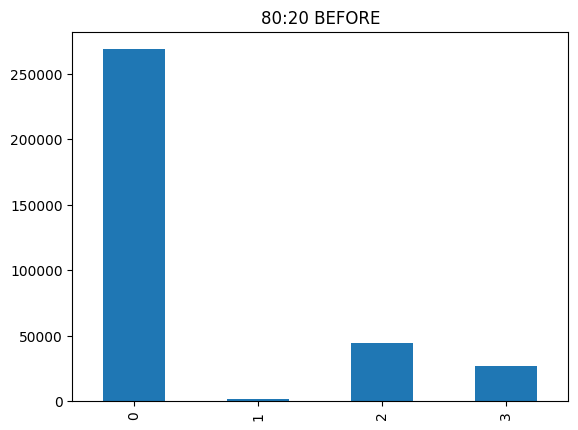

Train Data Class Distribution (BEFORE):
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


In [ ]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", 0.4)
run_split_adasyn_tomek(df, "70:30", 0.3)



========== 80:20 (ADASYN + Tomek Links) ==========


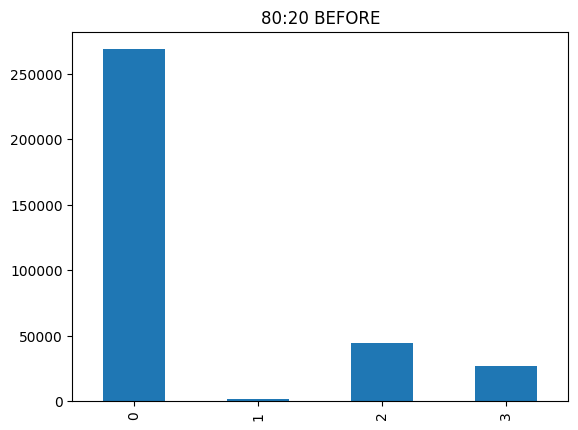

Train Data Class Distribution (BEFORE):
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


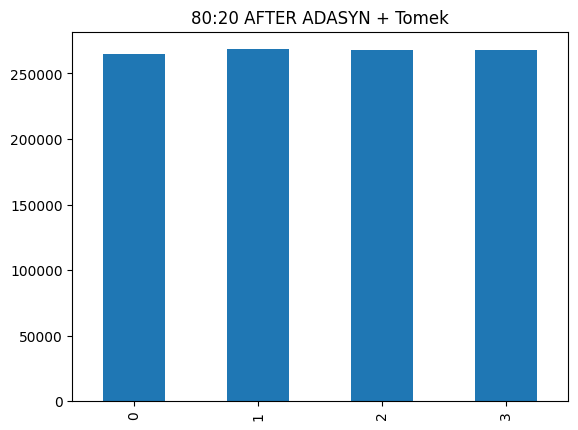

Train Data Class Distribution (AFTER):
0    264566
1    268367
2    267606
3    267605
Name: count, dtype: int64
Epoch 1: Loss=0.1404, TrainAcc=0.9496, TestAcc=0.9730, ROC-AUC=0.9983
Epoch 2: Loss=0.0387, TrainAcc=0.9882, TestAcc=0.9792, ROC-AUC=0.9992
Epoch 3: Loss=0.0294, TrainAcc=0.9916, TestAcc=0.9795, ROC-AUC=0.9992
Epoch 4: Loss=0.0245, TrainAcc=0.9927, TestAcc=0.9835, ROC-AUC=0.9992
Epoch 5: Loss=0.0221, TrainAcc=0.9936, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 6: Loss=0.0218, TrainAcc=0.9939, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 7: Loss=0.0201, TrainAcc=0.9942, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 8: Loss=0.0187, TrainAcc=0.9944, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 9: Loss=0.0185, TrainAcc=0.9947, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 10: Loss=0.0189, TrainAcc=0.9947, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 11: Loss=0.0175, TrainAcc=0.9948, TestAcc=0.9859, ROC-AUC=0.9996
Epoch 12: Loss=0.0171, TrainAcc=0.9949, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 13: Loss=0.0167, TrainAcc=0.9950, Test

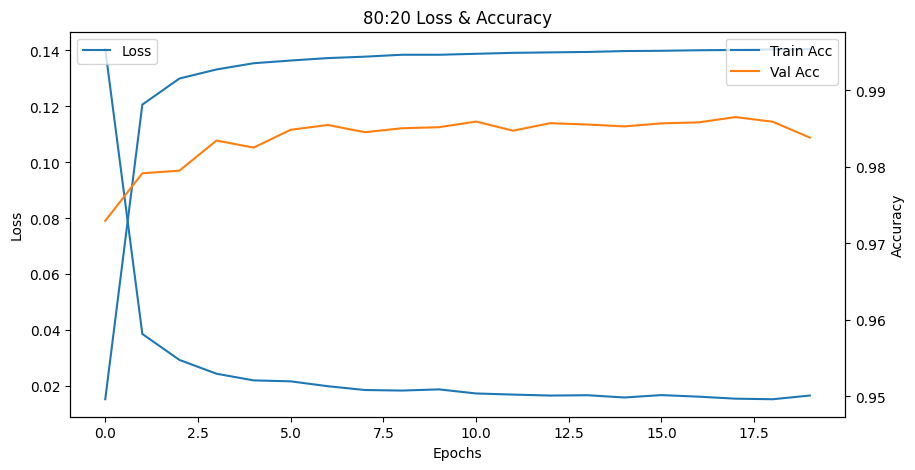

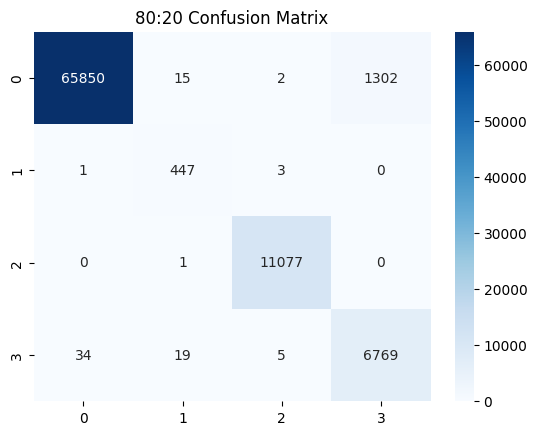

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.93      0.99      0.96       451
           2       1.00      1.00      1.00     11078
           3       0.84      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



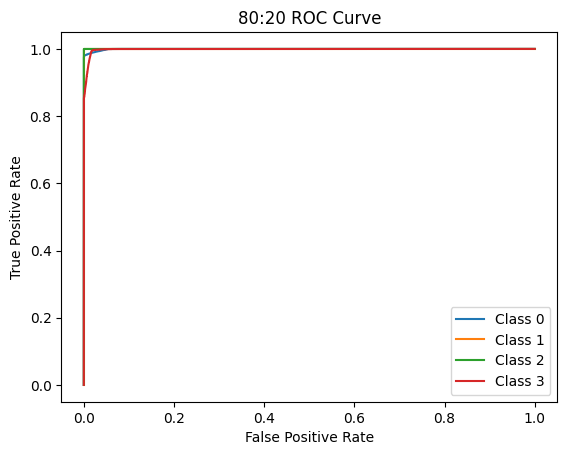

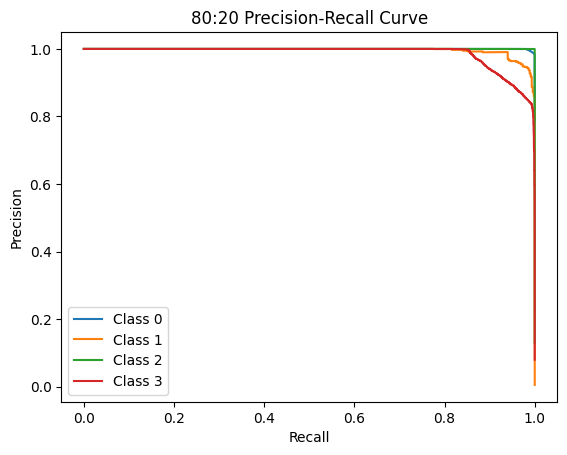

Runtime: 4403.76s
RAM Used: 1424.45 MB


In [9]:
df = clean_dataframe(pd.read_csv(DATA_PATH))
run_split_adasyn_tomek(df, "80:20", 0.2)

In [10]:
!pip install numpy